In [1]:
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [4]:
fake_df = pd.read_csv(r"C:\Users\ADMIN\Desktop\Fake_news\Fake.csv")
fake_df["target"] = "fake"

true_df = pd.read_csv(r"C:\Users\ADMIN\Desktop\Fake_news\True.csv")
true_df["target"] = "true"


In [8]:
fake_df["target"] = 0
true_df["target"] = 1

In [9]:
df = pd.concat([fake_df, true_df])

In [10]:
def clean_text(text):

    text = text.lower()  # lowercase

    text = re.sub(r'http\S+', '', text)  # remove links

    text = re.sub(r'\d+', '', text)  # remove numbers

    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation

    return text

In [11]:
df["clean_text"] = df["text"].apply(clean_text)


In [12]:
X = df["text"].str.lower()
y = df["target"]

In [13]:
tfidf = TfidfVectorizer(stop_words='english', max_features=9000)
X_vect = tfidf.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_vect, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
news_input =  "Aliens have officially signed a peace agreement with world leaders in Switzerland."

In [15]:
vect_input = tfidf.transform([ "Aliens have officially signed a peace agreement with world leaders in Switzerland.".lower()])
prediction = model.predict(vect_input)[0]
probability = model.predict_proba(vect_input)[0][prediction]

In [16]:
if prediction == 1:
    result = "Real News"
else:
    result = "Fake News"

print(f"The news is: {result} with a probability of {probability:.2f}")

The news is: Fake News with a probability of 0.88


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
prob_fake = probability if prediction == 0 else (1 - probability)
prob_real = probability if prediction == 1 else (1 - probability)

prob_df = pd.DataFrame({
    'News Type': ['Fake News', 'Real News'],
    'Probability': [prob_fake, prob_real]
})

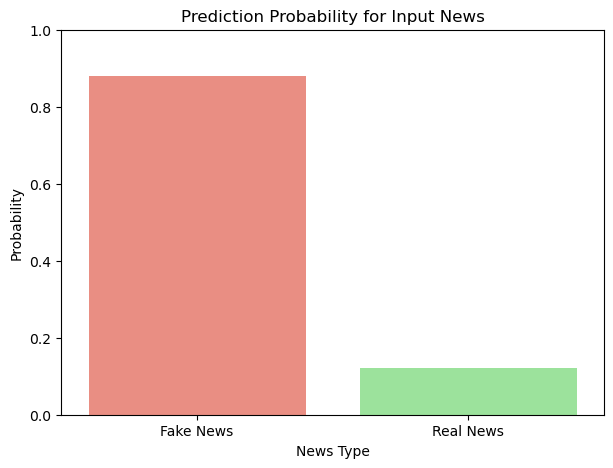

In [19]:
plt.figure(figsize=(7, 5))
sns.barplot(x='News Type', y='Probability', data=prob_df, hue='News Type', palette=['salmon', 'lightgreen'], legend=False)
plt.title('Prediction Probability for Input News')
plt.xlabel('News Type')
plt.ylabel('Probability')
plt.ylim(0, 1) # Ensure y-axis goes from 0 to 1 for probabilities
plt.show()

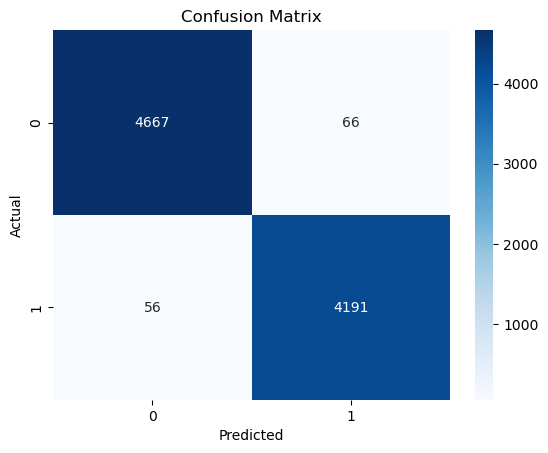

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualization
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

